# Finite-State Markov Chains: transition powers and stationarity

This experiment uses a two-state weather model to connect matrix multiplication with multi-step probabilities, simulation, and the stationary distribution. All reported results use fixed random seeds.

## 1. Problem

Suppose tomorrow's weather depends only on today's weather. With states ordered as Sunny and Rainy, let

$$P=\begin{pmatrix}0.8&0.2\\0.4&0.6\end{pmatrix},$$

where row $i$ gives the probabilities of tomorrow's state conditional on today's state $i$. We ask:

1. Why does $(P^n)_{ij}$ equal the probability of moving from state $i$ to state $j$ in $n$ steps?
2. What long-run distribution $\pi$ satisfies $\pi P=\pi$?
3. Do simulated state frequencies and transition probabilities agree with the matrix calculations?

## 2. Mathematical Background

The Markov property says that, given the present state, the future is conditionally independent of the earlier past:

$$P(X_{m+1}=j\mid X_m=i,X_{m-1},\ldots,X_0)=P_{ij}.$$

For two steps, condition on the intermediate state $k$ and apply the law of total probability:

$$P(X_2=j\mid X_0=i)=\sum_k P(X_1=k\mid X_0=i)P(X_2=j\mid X_1=k)=\sum_kP_{ik}P_{kj}.$$

The final sum is exactly the $(i,j)$ entry of $P^2$. Repeating the same conditioning proves by induction that the $n$-step transition matrix is $P^n$. If a row vector $\alpha_0$ describes the initial distribution, then

$$\alpha_n=\alpha_0P^n.$$

## 3. Theoretical Result

A stationary distribution is a probability row vector satisfying

$$\pi P=\pi,\qquad \pi_\text{Sunny}+\pi_\text{Rainy}=1.$$

For this weather matrix,

$$\pi_\text{Sunny}=0.8\pi_\text{Sunny}+0.4\pi_\text{Rainy},$$

so $0.2\pi_\text{Sunny}=0.4\pi_\text{Rainy}$ and therefore

$$\boxed{\pi=(2/3,\ 1/3).}$$

The eigenvalues of $P$ are 1 and 0.4. The component associated with 0.4 shrinks geometrically, so from a Sunny start

$$P(X_n=\text{Sunny}\mid X_0=\text{Sunny})=\frac23+\frac13(0.4)^n,$$

which converges to $2/3$. Because every entry of $P$ is positive, this finite chain is irreducible and aperiodic, so the stationary distribution is unique and the distribution converges to it from either starting state.

## 4. Numerical Experiment

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "src" / "markov_chain.py").exists(), "Run from the repository root or notebooks/"
sys.path.insert(0, str(project_root))

from src.markov_chain import (
    empirical_transition_matrix,
    n_step_transition,
    simulate_chains,
    stationary_distribution,
)

figure_dir = project_root / "figures"
figure_dir.mkdir(exist_ok=True)
states = ("Sunny", "Rainy")
P = np.array([[0.8, 0.2], [0.4, 0.6]])
pi = stationary_distribution(P)

print("P^2 =")
print(n_step_transition(P, 2))
print("\nP^5 =")
print(np.round(n_step_transition(P, 5), 6))
print(f"\nStationary distribution: Sunny={pi[0]:.6f}, Rainy={pi[1]:.6f}")
print("Check pi @ P:", np.round(pi @ P, 6))

P^2 =
[[0.72 0.28]
 [0.56 0.44]]

P^5 =
[[0.67008 0.32992]
 [0.65984 0.34016]]

Stationary distribution: Sunny=0.666667, Rainy=0.333333
Check pi @ P: [0.666667 0.333333]


In [2]:
n_steps = 30
n_paths = 50_000
paths = simulate_chains(P, initial_state=0, n_steps=n_steps, n_paths=n_paths,
                        rng=np.random.default_rng(20260929))
steps = np.arange(n_steps + 1)
empirical_sunny = np.mean(paths == 0, axis=0)
initial_sunny = np.array([1.0, 0.0])
theoretical = np.array([initial_sunny @ n_step_transition(P, n) for n in steps])

print(f"{'step':>6} {'empirical P(Sunny)':>22} {'theoretical P(Sunny)':>24} {'absolute error':>17}")
for n in (0, 1, 2, 5, 10, 20, 30):
    error = abs(empirical_sunny[n] - theoretical[n, 0])
    print(f"{n:6d} {empirical_sunny[n]:22.5f} {theoretical[n, 0]:24.5f} {error:17.5f}")

estimated_P = empirical_transition_matrix(paths, n_states=2)
print("\nTransition matrix estimated from all simulated moves:")
print(np.round(estimated_P, 5))

  step     empirical P(Sunny)     theoretical P(Sunny)    absolute error
     0                1.00000                  1.00000           0.00000
     1                0.79966                  0.80000           0.00034
     2                0.72114                  0.72000           0.00114
     5                0.66856                  0.67008           0.00152
    10                0.66472                  0.66670           0.00198
    20                0.66896                  0.66667           0.00229
    30                0.66428                  0.66667           0.00239

Transition matrix estimated from all simulated moves:
[[0.80014 0.19986]
 [0.39927 0.60073]]


The 50,000 paths all start Sunny. At each step, the empirical Sunny fraction estimates the first entry of $(1,0)P^n$. The transition matrix estimate pools every observed one-step move across all paths and time points.

## 5. Visualization

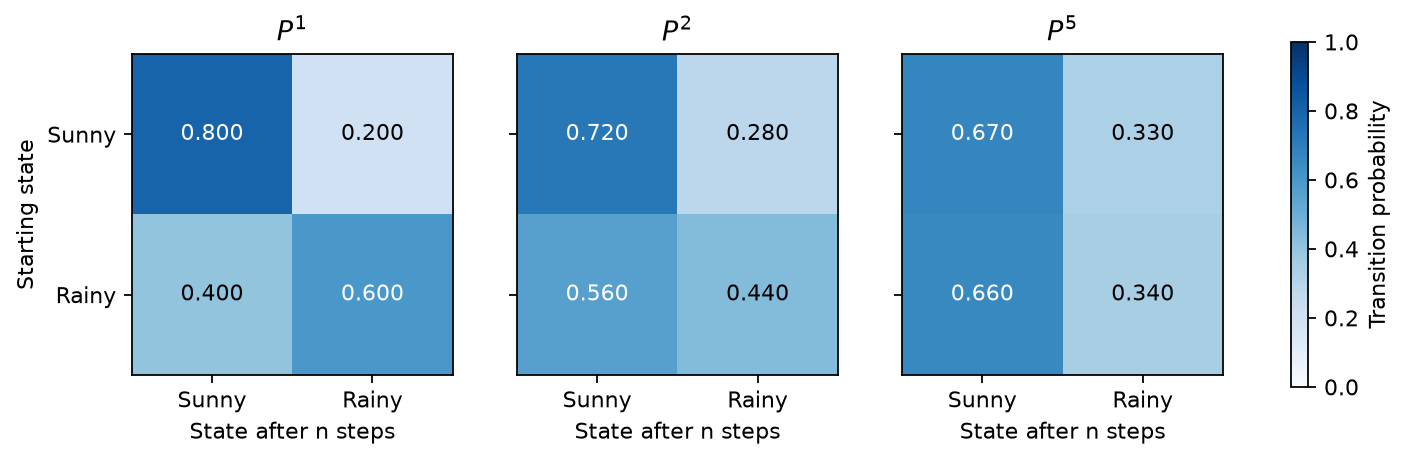

In [3]:
powers = (1, 2, 5)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, power in zip(axes, powers):
    matrix = n_step_transition(P, power)
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks(range(2), states)
    ax.set_xlabel("State after n steps")
    if power == 1:
        ax.set_yticks(range(2), states)
        ax.set_ylabel("Starting state")
    else:
        ax.set_yticks(range(2), ("", ""))
    ax.set_title(fr"$P^{power}$")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:.3f}", ha="center", va="center",
                    color="white" if matrix[i, j] > 0.55 else "black")
fig.colorbar(image, ax=axes, shrink=0.8, label="Transition probability")
path = figure_dir / "markov_transition_powers.png"
fig.savefig(path, dpi=160, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(path)))

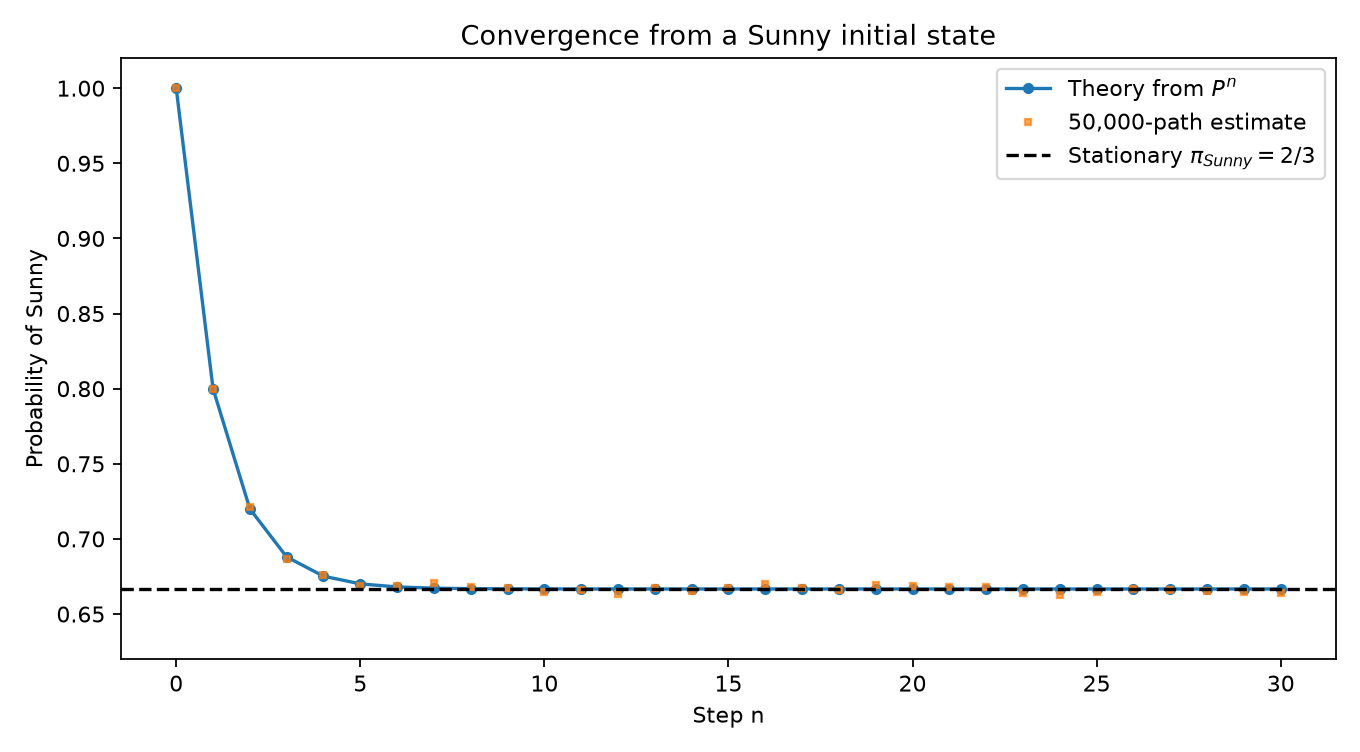

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.7))
ax.plot(steps, theoretical[:, 0], "o-", markersize=4, label="Theory from $P^n$")
ax.plot(steps, empirical_sunny, "s", markersize=3, alpha=0.7, label="50,000-path estimate")
ax.axhline(pi[0], color="black", linestyle="--", label=r"Stationary $\pi_{Sunny}=2/3$")
ax.set(title="Convergence from a Sunny initial state", xlabel="Step n",
       ylabel="Probability of Sunny", ylim=(0.62, 1.02))
ax.legend()
fig.tight_layout()
path = figure_dir / "markov_convergence_to_stationary.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

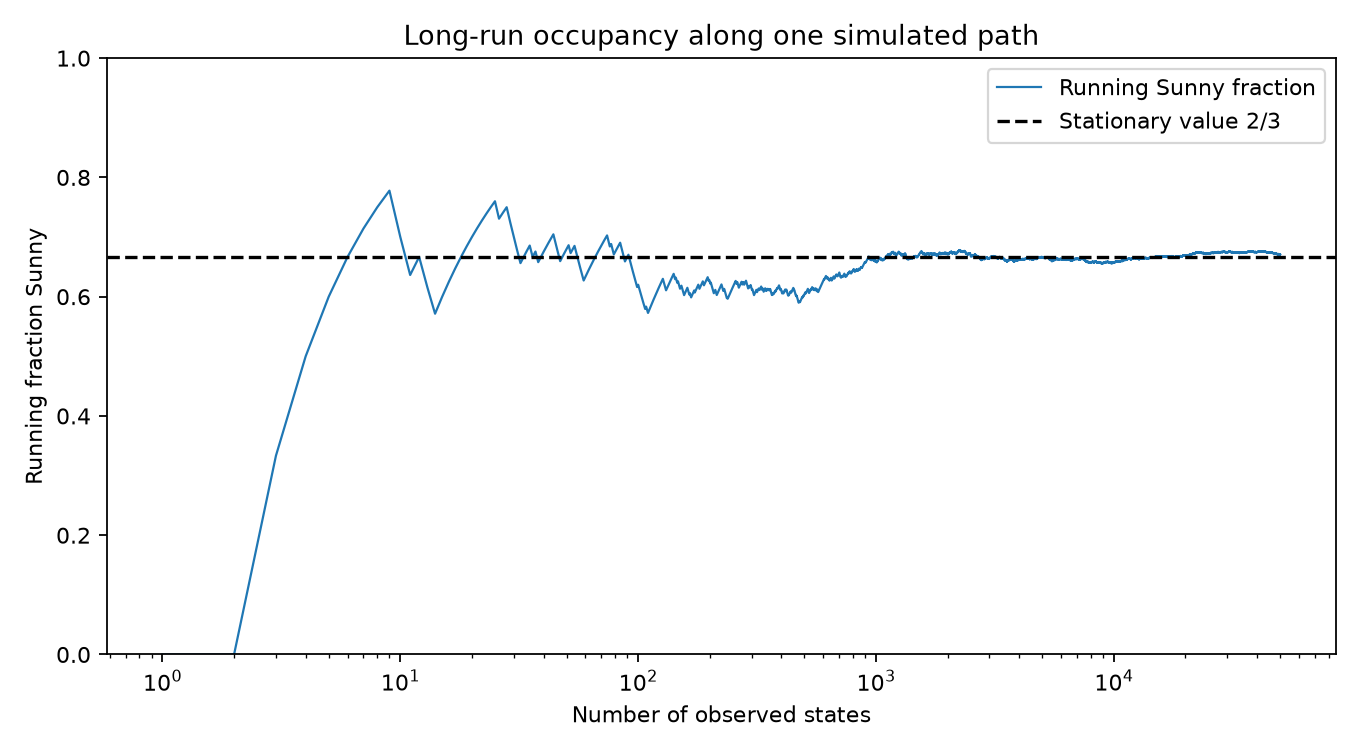

Sunny fraction over the full long path: 0.67089


In [5]:
long_path = simulate_chains(P, initial_state=1, n_steps=50_000, n_paths=1,
                            rng=np.random.default_rng(20260930))[0]
running_sunny_fraction = np.cumsum(long_path == 0) / np.arange(1, long_path.size + 1)

fig, ax = plt.subplots(figsize=(8.5, 4.7))
ax.plot(np.arange(1, long_path.size + 1), running_sunny_fraction, linewidth=1,
        label="Running Sunny fraction")
ax.axhline(pi[0], color="black", linestyle="--", label="Stationary value 2/3")
ax.set(xscale="log", title="Long-run occupancy along one simulated path",
       xlabel="Number of observed states", ylabel="Running fraction Sunny", ylim=(0, 1))
ax.legend()
fig.tight_layout()
path = figure_dir / "markov_long_run_occupancy.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

print(f"Sunny fraction over the full long path: {running_sunny_fraction[-1]:.5f}")

## 6. Comparison with Theory

The heatmaps show how the rows of $P^n$ become similar as $n$ increases: the chain increasingly forgets its starting state. The simulated Sunny probabilities closely track the first component of $(1,0)P^n$, while the limiting horizontal line is $2/3$.

The estimated one-step matrix should be close to the original $P$, which checks the simulation mechanism directly. The running occupancy of one long path checks a different result: for an irreducible, aperiodic finite chain, the long-run fraction of time in each state converges to the stationary distribution.

## 7. Interpretation

Matrix multiplication is doing probability bookkeeping. In $(P^2)_{ij}$, each term $P_{ik}P_{kj}$ is the probability of one possible two-step route through intermediate state $k$; summing over $k$ includes every route. Higher powers repeat the same operation.

Stationarity is a balance condition. If today's weather distribution is already $(2/3,1/3)$, applying one transition leaves that distribution unchanged. This does not mean the weather stops changing: individual paths continue switching states while the population proportions remain stable.

There are two distinct convergence statements here: the distribution across many independent paths approaches $\pi$, and the time average along one sufficiently long path approaches $\pi$. For this ergodic chain, both hold.

## 8. Limitations

- The model assumes the same transition probabilities every day and uses only today's state; real weather has seasonality and longer memory.
- A stationary distribution describes long-run proportions, not a fixed or deterministic weather sequence.
- Finite simulations contain sampling error, especially for rare transitions or small path counts.
- Reducible or periodic chains can behave differently: stationary distributions may not be unique, and $\alpha_0P^n$ need not converge in the same way.